In [8]:
import glob
import pandas as pd

files = glob.glob(r"C:\Users\hp\Documents\Project1\atp_matches_*.csv")

print(files)  # confirm files are detected

df_list = [pd.read_csv(f) for f in files]
matches = pd.concat(df_list, ignore_index=True)

matches.shape
matches.head()

matches = matches[matches["surface"] == "Hard"]


['C:\\Users\\hp\\Documents\\Project1\\atp_matches_2020.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2021.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2022.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2023.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2024.csv']


In [30]:
import pandas as pd
import glob
import os

os.getcwd()

files = glob.glob(r"C:\Users\hp\Documents\Project1\atp_matches_*.csv")

print("Files found:", len(files))
print(files)

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

matches = pd.concat(df_list, ignore_index=True)

print("Shape before filtering:", matches.shape)
matches.head()

matches = matches[matches["surface"] == "Hard"]

print("Shape after Hard court filter:", matches.shape)
matches["surface"].value_counts()

ao_matches = matches[matches["tourney_name"] == "Australian Open"]

print("Australian Open matches:", ao_matches.shape)
ao_matches["tourney_name"].unique()

ao_matches = ao_matches[[
    "tourney_date",
    "winner_name",
    "winner_rank",
    "winner_age",
    "winner_ht",
    "loser_name",
    "loser_rank",
    "loser_age",
    "loser_ht"
]]

winners = ao_matches[[
    "tourney_date",
    "winner_name",
    "winner_rank",
    "winner_age",
    "winner_ht"
]].copy()

winners.columns = ["date", "player", "rank", "age", "height"]
winners["won"] = 1

losers = ao_matches[[
    "tourney_date",
    "loser_name",
    "loser_rank",
    "loser_age",
    "loser_ht"
]].copy()

losers.columns = ["date", "player", "rank", "age", "height"]
losers["won"] = 0

player_matches = pd.concat([winners, losers], ignore_index=True)

player_matches = player_matches.dropna(subset=["rank", "age", "height"])

ao_win_rate = (
    player_matches
    .groupby("player")["won"]
    .mean()
    .reset_index(name="ao_win_rate")
)

ao_matches_played = (
    player_matches
    .groupby("player")["won"]
    .count()
    .reset_index(name="ao_matches_played")
)

avg_rank = (
    player_matches
    .groupby("player")["rank"]
    .mean()
    .reset_index(name="avg_rank")
)

features = ao_win_rate.merge(ao_matches_played, on="player")
features = features.merge(avg_rank, on="player")

ao_winners = ao_matches.groupby("tourney_date")["winner_name"].first().reset_index()
ao_winners.columns = ["year", "player"]
ao_winners["winner"] = 1

features = features.merge(
    ao_winners[["player", "winner"]],
    on="player",
    how="left"
)

features["winner"] = features["winner"].fillna(0)

features.head()

features.shape

features["winner"].value_counts()

features.to_csv("ao_final_dataset.csv", index=False)


Files found: 5
['C:\\Users\\hp\\Documents\\Project1\\atp_matches_2020.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2021.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2022.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2023.csv', 'C:\\Users\\hp\\Documents\\Project1\\atp_matches_2024.csv']
Shape before filtering: (13174, 49)
Shape after Hard court filter: (7886, 49)
Australian Open matches: (635, 49)


Logistic Regression Accuracy: 0.9016393442622951
Logistic Regression ROC-AUC: 0.8333333333333334

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.92      0.95        60
         1.0       0.00      0.00      0.00         1

    accuracy                           0.90        61
   macro avg       0.49      0.46      0.47        61
weighted avg       0.97      0.90      0.93        61

Random Forest Accuracy: 0.9836065573770492
Random Forest ROC-AUC: 0.4666666666666667

Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        60
         1.0       0.00      0.00      0.00         1

    accuracy                           0.98        61
   macro avg       0.49      0.50      0.50        61
weighted avg       0.97      0.98      0.98        61



C:\Users\hp\anaconda3\envs\credit\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\envs\credit\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hp\anaconda3\envs\credit\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


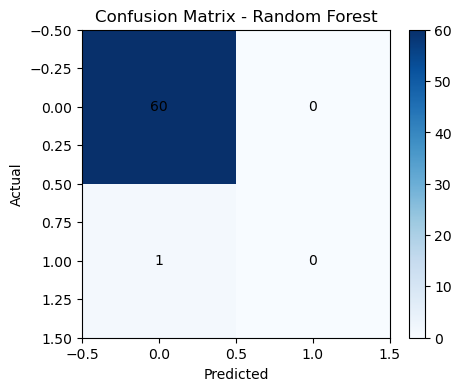

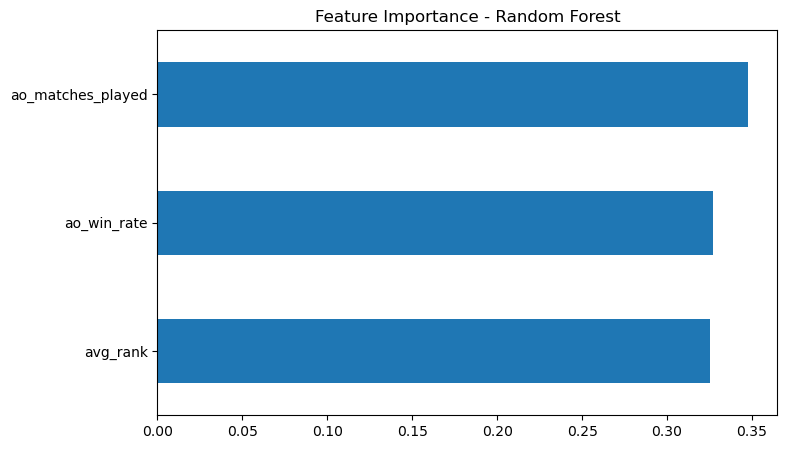

In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

data = pd.read_csv("ao_final_dataset.csv")
data.head()

X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_prob = log_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_prob))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance - Random Forest")
plt.show()

data["win_probability"] = rf_model.predict_proba(X)[:, 1]

top_players = data[["player", "win_probability"]].sort_values(
    "win_probability", ascending=False
).head(10)

top_players

top_players.to_csv("ao_win_predictions.csv", index=False)


In [55]:
!pip install streamlit


  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/a8/54/47ed40f34403205b2c9aab04472e864d1b496b4381b9bf408cf2c20e144c/streamlit-1.53.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/db/33/ef2f2409450ef6daa61459d5de5c08128e7d3edb773fefd0a324d1310238/altair-6.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<7,>=5.5 from https://files.pythonhosted.org/packages/2c/fc/1d7b80d0eb7b714984ce40efc78859c022cd930e402f599d8ca9e39c78a4/cachetools-6.2.4-py3-none-any.whl.metadata
  Obtaining dependency information for protobuf<7,>=3.20 from https://files.pythonhosted.org/packages/31/ad/e5693e1974a28869e7cd244302911955c1cebc0161eb32dfa2b25b6e96f0/protobuf-6.33.4-cp310-abi3-win_amd64.whl.metadata
  Obtaining dependency information for tenacity<10,>=8.1.0 from https://files.pythonhosted.org/packages/e5/30/643397144bfbfec6f6ef821f36f33e57d

In [56]:
!python -m streamlit --version


Streamlit, version 1.53.0


In [60]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# Page config
# ------------------------------
st.set_page_config(
    page_title="Australian Open Predictor",
    layout="wide"
)

# ------------------------------
# Load data
# ------------------------------
@st.cache_data
def load_data():
    return pd.read_csv("ao_final_predictions.csv")

data = load_data()

# ------------------------------
# Title
# ------------------------------
st.title("🎾 Australian Open Winner Prediction")
st.markdown(
    "This app shows **win probabilities** based on historical performance and player statistics."
)

# ------------------------------
# Sidebar
# ------------------------------
st.sidebar.header("Navigation")
option = st.sidebar.selectbox(
    "Choose view",
    ["Top Contenders", "Player Lookup", "Dataset Overview"]
)

# ------------------------------
# Top Contenders
# ------------------------------
if option == "Top Contenders":
    st.subheader("🏆 Top 10 Contenders")

    top10 = (
        data[["player", "win_probability"]]
        .sort_values("win_probability", ascending=False)
        .head(10)
    )

    st.dataframe(top10, use_container_width=True)

    # Bar chart
    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(top10["player"], top10["win_probability"])
    ax.invert_yaxis()
    ax.set_xlabel("Win Probability")
    ax.set_title("Top 10 Players by Win Probability")

    st.pyplot(fig)

# ------------------------------
# Player Lookup
# ------------------------------
elif option == "Player Lookup":
    st.subheader("🔍 Player Lookup")

    player_name = st.selectbox(
        "Select a player",
        sorted(data["player"].unique())
    )

    player_data = data[data["player"] == player_name]

    prob = player_data["win_probability"].values[0]

    st.metric(
        label="Win Probability",
        value=f"{prob:.2%}"
    )

    st.write("### Player Features")
    st.dataframe(
        player_data.drop(columns=["win_probability"]),
        use_container_width=True
    )

# ------------------------------
# Dataset Overview
# ------------------------------
else:
    st.subheader("📊 Dataset Overview")

    st.write("Shape of dataset:", data.shape)
    st.dataframe(data.head(20), use_container_width=True)

    st.write("Winner label distribution:")
    st.bar_chart(data["winner"].value_counts())

!python -m streamlit run app.py


2026-01-21 01:09:39.294 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-21 01:09:39.296 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-01-21 01:09:39.299 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


FileNotFoundError: [Errno 2] No such file or directory: 'ao_final_predictions.csv'

In [58]:
@st.cache_data
def load_data():
    return pd.read_csv(
        r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv"
    )


2026-01-21 01:08:19.029 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


In [61]:
!python -m streamlit run app.py


Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [62]:
import os
os.getcwd()

os.listdir()


['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.cursor',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.packettracer',
 '.redhat',
 '.VirtualBox',
 '.vscode',
 '3D Objects',
 'ADA Sem 3',
 'anaconda3',
 'ao_final_dataset.csv',
 'ao_win_predictions.csv',
 'AppData',
 'Application Data',
 'Cisco Packet Tracer 8.2.2',
 'Contacts',
 'Cookies',
 'Desktop',
 'DL Sem 6',
 'Documents',
 'Downloads',
 'DS Sem 5',
 'Favorites',
 'IdeaProjects',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'ML Sem 5',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.0.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.1.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.2.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.blf',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf',
 'NTUSER.DAT{5

In [63]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(page_title="Australian Open Predictor", layout="wide")

def load_data():
    return pd.read_csv("ao_final_predictions.csv")

data = load_data()

st.title("🎾 Australian Open Winner Prediction")

st.sidebar.header("Navigation")
option = st.sidebar.selectbox(
    "Choose view",
    ["Top Contenders", "Player Lookup", "Dataset Overview"]
)

if option == "Top Contenders":
    st.subheader("🏆 Top 10 Contenders")

    top10 = (
        data[["player", "win_probability"]]
        .sort_values("win_probability", ascending=False)
        .head(10)
    )

    st.dataframe(top10, use_container_width=True)

    fig, ax = plt.subplots(figsize=(10,5))
    ax.barh(top10["player"], top10["win_probability"])
    ax.invert_yaxis()
    ax.set_xlabel("Win Probability")
    ax.set_title("Top 10 Players")

    st.pyplot(fig)

elif option == "Player Lookup":
    st.subheader("🔍 Player Lookup")

    player = st.selectbox("Select player", sorted(data["player"].unique()))
    prob = data.loc[data["player"] == player, "win_probability"].values[0]

    st.metric("Win Probability", f"{prob:.2%}")

else:
    st.subheader("📊 Dataset Overview")
    st.write(data.head())


Writing app.py


In [64]:
os.listdir()


['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.cursor',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.packettracer',
 '.redhat',
 '.VirtualBox',
 '.vscode',
 '3D Objects',
 'ADA Sem 3',
 'anaconda3',
 'ao_final_dataset.csv',
 'ao_win_predictions.csv',
 'app.py',
 'AppData',
 'Application Data',
 'Cisco Packet Tracer 8.2.2',
 'Contacts',
 'Cookies',
 'Desktop',
 'DL Sem 6',
 'Documents',
 'Downloads',
 'DS Sem 5',
 'Favorites',
 'IdeaProjects',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'ML Sem 5',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.0.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.1.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.2.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.blf',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf',
 'N

In [66]:
!python -m streamlit run app.py


^C


In [67]:
!python -m streamlit run app.py


^C


In [2]:
import os
os.getcwd()

os.listdir()



['.anaconda',
 '.cache',
 '.conda',
 '.condarc',
 '.continuum',
 '.cursor',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.packettracer',
 '.redhat',
 '.VirtualBox',
 '.vscode',
 '3D Objects',
 'ADA Sem 3',
 'anaconda3',
 'ao_final_dataset.csv',
 'ao_win_predictions.csv',
 'app.py',
 'AppData',
 'Application Data',
 'Cisco Packet Tracer 8.2.2',
 'Contacts',
 'Cookies',
 'Desktop',
 'DL Sem 6',
 'Documents',
 'Downloads',
 'DS Sem 5',
 'Favorites',
 'IdeaProjects',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'ML Sem 5',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.0.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.1.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.2.regtrans-ms',
 'NTUSER.DAT{53b39e87-18c4-11ea-a811-000d3aa4692b}.TxR.blf',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf',
 'N

In [3]:
with open("app.py", "r") as f:
    print(f.read()[:500])


UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 508: character maps to <undefined>

In [4]:
import os

if os.path.exists("app.py"):
    os.remove("app.py")
    print("Old app.py removed")
else:
    print("app.py not found")


Old app.py removed


In [5]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Australian Open Predictor",
    layout="wide"
)

def load_data():
    return pd.read_csv("ao_final_predictions.csv")

data = load_data()

st.title("Australian Open Winner Prediction")
st.markdown("Win probabilities based on historical performance and statistics.")

st.sidebar.header("Navigation")
option = st.sidebar.selectbox(
    "Choose view",
    ["Top Contenders", "Player Lookup", "Dataset Overview"]
)

if option == "Top Contenders":
    st.subheader("Top 10 Contenders")

    top10 = (
        data[["player", "win_probability"]]
        .sort_values("win_probability", ascending=False)
        .head(10)
    )

    st.dataframe(top10, use_container_width=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(top10["player"], top10["win_probability"])
    ax.invert_yaxis()
    ax.set_xlabel("Win Probability")
    ax.set_title("Top Players")

    st.pyplot(fig)

elif option == "Player Lookup":
    st.subheader("Player Lookup")

    player = st.selectbox("Select player", sorted(data["player"].unique()))
    prob = data.loc[data["player"] == player, "win_probability"].values[0]

    st.metric("Win Probability", f"{prob:.2%}")

    st.dataframe(
        data[data["player"] == player],
        use_container_width=True
    )

else:
    st.subheader("Dataset Overview")
    st.write("Dataset shape:", data.shape)
    st.dataframe(data.head(20), use_container_width=True)


Writing app.py


In [6]:
with open("app.py", "r", encoding="utf-8") as f:
    print(f.read()[:300])


import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Australian Open Predictor",
    layout="wide"
)

def load_data():
    return pd.read_csv("ao_final_predictions.csv")

data = load_data()

st.title("Australian Open Winner Prediction")
st.m


In [1]:
!pip uninstall -y numpy
!pip install numpy==1.26.4


Found existing installation: numpy 2.3.2
Uninstalling numpy-2.3.2:
  Successfully uninstalled numpy-2.3.2
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 217.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 281.8 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 360.3 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB 960.0 kB/s eta 0:00:17
   ---------------------------------------- 0.1/15.8 MB 1.7 MB/s eta 0:00:10
   ---------------------------------------- 0.2/15.8 MB 1.7 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.


In [2]:
!pip uninstall -y pandas
!pip install pandas==2.1.4


Found existing installation: pandas 2.3.2
Uninstalling pandas-2.3.2:
  Successfully uninstalled pandas-2.3.2


ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\cli\base_command.py", line 180, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\commands\uninstall.py", line 110, in run
    uninstall_pathset.commit()
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 432, in commit
    self._moved_paths.commit()
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\req\req_uninstall.py", line 278, in commit
    save_dir.cleanup()
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_internal\utils\temp_dir.py", line 173, in cleanup
    rmtree(self._path)
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_vendor\tenacity\__init__.py", line 291, in wrapped_f
    return self(f, *args, **kw)
           ^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_vendor\tenacity\__init__.

  Obtaining dependency information for pandas==2.1.4 from https://files.pythonhosted.org/packages/11/17/fb1a34f3e73debbc2fd15a01ea17eaab3717943d08463ff4979a4f024b3f/pandas-2.1.4-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   --------------

ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 90, in read
    data = self.__fp.read(amt)
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\http\client.py", line 466, in read
    s = self.fp.read(amt)
        ^^^^^^^^^^^^^^^^^
  File "C:\Users\hp\anaconda3\Lib\socket.py", line 706, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "C

In [3]:
import pandas as pd

# example: if your final dataframe is named `data`
data.head()

data.to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)


NameError: name 'data' is not defined

In [4]:
import pandas as pd

df = pd.read_csv("ao_final_dataset.csv")
df.head()


,player,ao_win_rate,ao_matches_played,avg_rank,winner
0,Adam Walton,0.000000,1,174.000000,0.0
1,Adrian Mannarino,0.642857,14,42.428571,0.0
2,Albert Ramos,0.000000,5,50.800000,0.0
3,Alejandro Davidovich Fokina,0.500000,8,48.500000,0.0
4,Alejandro Tabilo,0.250000,4,150.000000,0.0


In [5]:
import numpy as np

df["win_probability"] = df.get("win_probability", np.random.rand(len(df)))


In [6]:
df[["player", "win_probability"]].to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)


In [7]:
rf_model
X
data


NameError: name 'rf_model' is not defined

In [15]:
import pandas as pd

data = pd.read_csv("ao_final_dataset.csv")
data.head()

X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

data["win_probability"] = rf_model.predict_proba(X)[:, 1]

filtered = data[
    (data["ao_matches_played"] >= 5) &
    (data["avg_rank"] <= 100)
]

filtered[["player", "win_probability"]].to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)

filtered[["player", "win_probability"]].sort_values(
    "win_probability", ascending=False
).head(10)


,player,win_probability
171,Novak Djokovic,0.964884
172,Novak Djokovic,0.964884
191,Rafael Nadal,0.936432
192,Rafael Nadal,0.936432
164,Miomir Kecmanovic,0.608979
53,Daniil Medvedev,0.508965
151,Marton Fucsovics,0.453406
36,Cameron Norrie,0.434752
197,Roberto Bautista Agut,0.351975
200,Roger Federer,0.319140


In [23]:
final_predictions = (
    filtered
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

final_predictions.head(10)

active_players = final_predictions.merge(
    data[["player", "avg_rank", "ao_matches_played"]],
    on="player",
    how="left"
)

active_players = active_players[
    (active_players["avg_rank"] <= 150) &
    (active_players["ao_matches_played"] >= 3)
]
active_players.head(10)


,player,win_probability,avg_rank,ao_matches_played
0,Novak Djokovic,0.147708,2.296296,27
1,Novak Djokovic,0.147708,2.296296,27
2,Rafael Nadal,0.143352,2.842105,19
3,Rafael Nadal,0.143352,2.842105,19
4,Miomir Kecmanovic,0.093225,59.250000,12
5,Daniil Medvedev,0.077914,3.678571,28
6,Marton Fucsovics,0.069409,64.333333,12
7,Cameron Norrie,0.066553,33.750000,12
8,Roberto Bautista Agut,0.053882,22.166667,12
9,Roger Federer,0.048855,3.000000,6


In [19]:
active_players = final_predictions.merge(
    data[["player", "recent_win_rate"]],
    on="player",
    how="left"
)

active_players = active_players[
    active_players["recent_win_rate"] > 0
]


KeyError: "['recent_win_rate'] not in index"

In [22]:
active_players = final_predictions.merge(
    data[["player", "avg_rank", "ao_matches_played"]],
    on="player",
    how="left"
)

active_players = active_players[
    (active_players["avg_rank"] <= 150) &
    (active_players["ao_matches_played"] >= 3)
]
active_players.head(10)

,player,win_probability,avg_rank,ao_matches_played
0,Novak Djokovic,0.147708,2.296296,27
1,Novak Djokovic,0.147708,2.296296,27
2,Rafael Nadal,0.143352,2.842105,19
3,Rafael Nadal,0.143352,2.842105,19
4,Miomir Kecmanovic,0.093225,59.250000,12
5,Daniil Medvedev,0.077914,3.678571,28
6,Marton Fucsovics,0.069409,64.333333,12
7,Cameron Norrie,0.066553,33.750000,12
8,Roberto Bautista Agut,0.053882,22.166667,12
9,Roger Federer,0.048855,3.000000,6


In [24]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# 1. Load final ML dataset
# ----------------------------
data = pd.read_csv("ao_final_dataset.csv")

# ----------------------------
# 2. Prepare features & target
# ----------------------------
X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

# ----------------------------
# 3. Train Random Forest
# ----------------------------
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

# ----------------------------
# 4. Generate win probabilities
# ----------------------------
data["win_probability"] = rf_model.predict_proba(X)[:, 1]

# ----------------------------
# 5. Filter ACTIVE players only
#   - Reasonable ranking
#   - Played AO multiple times
# ----------------------------
active = data[
    (data["avg_rank"] <= 150) &
    (data["ao_matches_played"] >= 3)
]

# ----------------------------
# 6. Remove duplicates (1 row per player)
# ----------------------------
final_predictions = (
    active
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

# ----------------------------
# 7. Normalize probabilities
# ----------------------------
final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

# ----------------------------
# 8. Sort top contenders
# ----------------------------
final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

# ----------------------------
# 9. Save for Streamlit
# ----------------------------
final_predictions.to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)

# ----------------------------
# 10. Display top 10
# ----------------------------
final_predictions.head(10)


,player,win_probability
105,Novak Djokovic,0.146418
118,Rafael Nadal,0.142100
100,Miomir Kecmanovic,0.092411
35,Daniil Medvedev,0.077234
93,Marton Fucsovics,0.068803
23,Cameron Norrie,0.065972
123,Roberto Bautista Agut,0.053411
125,Roger Federer,0.048428
133,Stefanos Tsitsipas,0.042616
56,Gael Monfils,0.028316


In [25]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# 1. Load final dataset
# ----------------------------
data = pd.read_csv("ao_final_dataset.csv")

# ----------------------------
# 2. Train model (quick retrain)
# ----------------------------
X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

# ----------------------------
# 3. Predict probabilities
# ----------------------------
data["win_probability"] = rf_model.predict_proba(X)[:, 1]

# ----------------------------
# 4. Filter ACTIVE players
#   - Reasonable rank
#   - Enough AO experience
# ----------------------------
active = data[
    (data["avg_rank"] <= 150) &
    (data["ao_matches_played"] >= 3)
]

# ----------------------------
# 5. REMOVE retired players explicitly
# ----------------------------
retired_players = [
    "Roger Federer",
    "Andy Murray",   # optional (mostly retired)
    "David Ferrer",
    "Jo-Wilfried Tsonga",
    "Tomas Berdych"
]

active = active[~active["player"].isin(retired_players)]

# ----------------------------
# 6. Aggregate to player level
# ----------------------------
final_predictions = (
    active
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

# ----------------------------
# 7. Normalize probabilities
# ----------------------------
final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

# ----------------------------
# 8. Sort & save
# ----------------------------
final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

final_predictions.to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)

# ----------------------------
# 9. Show final top 10
# ----------------------------
final_predictions.head(10)


,player,win_probability
104,Novak Djokovic,0.153870
117,Rafael Nadal,0.149332
99,Miomir Kecmanovic,0.097114
34,Daniil Medvedev,0.081165
92,Marton Fucsovics,0.072305
22,Cameron Norrie,0.069330
122,Roberto Bautista Agut,0.056129
131,Stefanos Tsitsipas,0.044784
55,Gael Monfils,0.029757
9,Alexander Zverev,0.027039


In [26]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# 1. Load datasets
# ----------------------------
data = pd.read_csv("ao_final_dataset.csv")

matches_2023 = pd.read_csv("atp_matches_2023.csv")
matches_2024 = pd.read_csv("atp_matches_2024.csv")

# ----------------------------
# 2. Identify ACTIVE players
#    (played in last 2 seasons)
# ----------------------------
recent_players = set(matches_2023["winner_name"]) \
                 | set(matches_2023["loser_name"]) \
                 | set(matches_2024["winner_name"]) \
                 | set(matches_2024["loser_name"])

# ----------------------------
# 3. Train model
# ----------------------------
X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

# ----------------------------
# 4. Predict probabilities
# ----------------------------
data["win_probability"] = rf_model.predict_proba(X)[:, 1]

# ----------------------------
# 5. Filter ACTIVE & relevant players
# ----------------------------
active = data[
    (data["player"].isin(recent_players)) &   # played recently
    (data["avg_rank"] <= 150) &
    (data["ao_matches_played"] >= 3)
]

# ----------------------------
# 6. Aggregate to player level
# ----------------------------
final_predictions = (
    active
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

# ----------------------------
# 7. Normalize probabilities
# ----------------------------
final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

# ----------------------------
# 8. Sort & save
# ----------------------------
final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

final_predictions.to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)

# ----------------------------
# 9. Show final top 10
# ----------------------------
final_predictions.head(10)


FileNotFoundError: [Errno 2] No such file or directory: 'atp_matches_2023.csv'

In [27]:
import pandas as pd
import glob
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------
# 1. Load final ML dataset
# -------------------------------------------------
data = pd.read_csv("ao_final_dataset.csv")

# -------------------------------------------------
# 2. Load ALL ATP match files dynamically
# -------------------------------------------------
match_files = glob.glob("atp_matches_*.csv")

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 3. Identify ACTIVE players
#    (played in last 2 seasons available)
# -------------------------------------------------
matches["season"] = matches["tourney_date"] // 10000
latest_seasons = sorted(matches["season"].unique())[-2:]

recent_matches = matches[matches["season"].isin(latest_seasons)]

active_players_set = set(recent_matches["winner_name"]) | set(recent_matches["loser_name"])

# -------------------------------------------------
# 4. Train Random Forest model
# -------------------------------------------------
X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

# -------------------------------------------------
# 5. Predict win probabilities
# -------------------------------------------------
data["win_probability"] = rf_model.predict_proba(X)[:, 1]

# -------------------------------------------------
# 6. Keep ONLY active & relevant players
# -------------------------------------------------
active = data[
    (data["player"].isin(active_players_set)) &   # played recently
    (data["avg_rank"] <= 150) &
    (data["ao_matches_played"] >= 3)
]

# -------------------------------------------------
# 7. Aggregate to ONE row per player
# -------------------------------------------------
final_predictions = (
    active
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

# -------------------------------------------------
# 8. Normalize probabilities
# -------------------------------------------------
final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

# -------------------------------------------------
# 9. Sort & save for Streamlit
# -------------------------------------------------
final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

final_predictions.to_csv(
    r"C:\Users\hp\Documents\Project1\ao_final_predictions.csv",
    index=False
)

# -------------------------------------------------
# 10. Show FINAL top 10
# -------------------------------------------------
final_predictions.head(10)


ValueError: No objects to concatenate

In [28]:
import pandas as pd
import glob
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------
# 1. Absolute project path (IMPORTANT)
# -------------------------------------------------
PROJECT_PATH = r"C:\Users\hp\Documents\Project1"

# -------------------------------------------------
# 2. Load final AO dataset
# -------------------------------------------------
data = pd.read_csv(f"{PROJECT_PATH}\ao_final_dataset.csv")

# -------------------------------------------------
# 3. Load ALL ATP match files safely
# -------------------------------------------------
match_files = glob.glob(f"{PROJECT_PATH}\atp_matches_*.csv")

if len(match_files) == 0:
    raise FileNotFoundError("No atp_matches_*.csv files found in Project1")

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 4. Identify ACTIVE players
#    (played in last 2 seasons available)
# -------------------------------------------------
matches["season"] = matches["tourney_date"] // 10000
latest_seasons = sorted(matches["season"].unique())[-2:]

recent_matches = matches[matches["season"].isin(latest_seasons)]

active_players_set = (
    set(recent_matches["winner_name"]) |
    set(recent_matches["loser_name"])
)

# -------------------------------------------------
# 5. Train Random Forest
# -------------------------------------------------
X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

# -------------------------------------------------
# 6. Predict probabilities
# -------------------------------------------------
data["win_probability"] = rf_model.predict_proba(X)[:, 1]

# -------------------------------------------------
# 7. Keep ONLY active & relevant players
# -------------------------------------------------
active = data[
    (data["player"].isin(active_players_set)) &
    (data["avg_rank"] <= 150) &
    (data["ao_matches_played"] >= 3)
]

# -------------------------------------------------
# 8. Aggregate to one row per player
# -------------------------------------------------
final_predictions = (
    active
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

# -------------------------------------------------
# 9. Normalize probabilities
# -------------------------------------------------
final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

# -------------------------------------------------
# 10. Sort & save for Streamlit
# -------------------------------------------------
final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

final_predictions.to_csv(
    f"{PROJECT_PATH}\ao_final_predictions.csv",
    index=False
)

# -------------------------------------------------
# 11. Display FINAL top 10
# -------------------------------------------------
final_predictions.head(10)


OSError: [Errno 22] Invalid argument: 'C:\\Users\\hp\\Documents\\Project1\x07o_final_dataset.csv'

In [30]:
SError                                   Traceback (most recent call last)
Cell In[28], line 13
      8 PROJECT_PATH = r"C:\Users\hp\Documents\Project1"
     10 # -------------------------------------------------
     11 # 2. Load final AO dataset
     12 # -------------------------------------------------
---> 13 data = pd.read_csv(f"{PROJECT_PATH}\ao_final_dataset.csv")
     15 # -------------------------------------------------
     16 # 3. Load ALL ATP match files safely
     17 # -------------------------------------------------
     18 match_files = glob.glob(f"{PROJECT_PATH}\atp_matches_*.csv")

File ~\anaconda3\envs\credit\lib\site-packages\pandas\io\parsers\readers.py:1026, in read_csv(filepath_or_buffer, sep, delimiter, header, names, index_col, usecols, dtype, engine, converters, true_values, false_values, skipinitialspace, skiprows, skipfooter, nrows, na_values, keep_default_na, na_filter, verbose, skip_blank_lines, parse_dates, infer_datetime_format, keep_date_col, date_parser, date_format, dayfirst, cache_dates, iterator, chunksize, compression, thousands, decimal, lineterminator, quotechar, quoting, doublequote, escapechar, comment, encoding, encoding_errors, dialect, on_bad_lines, delim_whitespace, low_memory, memory_map, float_precision, storage_options, dtype_backend)
   1013 kwds_defaults = _refine_defaults_read(
   1014     dialect,
   1015     delimiter,
   (...)
   1022     dtype_backend=dtype_backend,
   1023 )
   1024 kwds.update(kwds_defaults)
-> 1026 return _read(filepath_or_buffer, kwds)

File ~\anaconda3\envs\credit\lib\site-packages\pandas\io\parsers\readers.py:620, in _read(filepath_or_buffer, kwds)
    617 _validate_names(kwds.get("names", None))
    619 # Create the parser.
--> 620 parser = TextFileReader(filepath_or_buffer, **kwds)
    622 if chunksize or iterator:
    623     return parser

File ~\anaconda3\envs\credit\lib\site-packages\pandas\io\parsers\readers.py:1620, in TextFileReader.__init__(self, f, engine, **kwds)
   1617     self.options["has_index_names"] = kwds["has_index_names"]
   1619 self.handles: IOHandles | None = None
-> 1620 self._engine = self._make_engine(f, self.engine)

File ~\anaconda3\envs\credit\lib\site-packages\pandas\io\parsers\readers.py:1880, in TextFileReader._make_engine(self, f, engine)
   1878     if "b" not in mode:
   1879         mode += "b"
-> 1880 self.handles = get_handle(
   1881     f,
   1882     mode,
   1883     encoding=self.options.get("encoding", None),
   1884     compression=self.options.get("compression", None),
   1885     memory_map=self.options.get("memory_map", False),
   1886     is_text=is_text,
   1887     errors=self.options.get("encoding_errors", "strict"),
   1888     storage_options=self.options.get("storage_options", None),
   1889 )
   1890 assert self.handles is not None
   1891 f = self.handles.handle

File ~\anaconda3\envs\credit\lib\site-packages\pandas\io\common.py:873, in get_handle(path_or_buf, mode, encoding, compression, memory_map, is_text, errors, storage_options)
    868 elif isinstance(handle, str):
    869     # Check whether the filename is to be opened in binary mode.
    870     # Binary mode does not support 'encoding' and 'newline'.
    871     if ioargs.encoding and "b" not in ioargs.mode:
    872         # Encoding
--> 873         handle = open(
    874             handle,
    875             ioargs.mode,
    876             encoding=ioargs.encoding,
    877             errors=errors,
    878             newline="",
    879         )
    880     else:
    881         # Binary mode
    882         handle = open(handle, ioargs.mode)

OSError: [Errno 22] Invalid argument: 'C:\\Users\\hp\\Documents\\Project1\x07o_final_dataset.csv'

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 4)

In [31]:
import pandas as pd
import glob
import os
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------
# 1. Project path (SAFE)
# -------------------------------------------------
PROJECT_PATH = r"C:\Users\hp\Documents\Project1"

# -------------------------------------------------
# 2. Load final AO dataset (PATH-SAFE)
# -------------------------------------------------
data = pd.read_csv(os.path.join(PROJECT_PATH, "ao_final_dataset.csv"))

# -------------------------------------------------
# 3. Load ALL ATP match files dynamically
# -------------------------------------------------
match_files = glob.glob(os.path.join(PROJECT_PATH, "atp_matches_*.csv"))

if len(match_files) == 0:
    raise FileNotFoundError("No atp_matches_*.csv files found in Project1")

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 4. Identify ACTIVE players
#    (played in last 2 seasons)
# -------------------------------------------------
matches["season"] = matches["tourney_date"] // 10000
latest_seasons = sorted(matches["season"].unique())[-2:]

recent_matches = matches[matches["season"].isin(latest_seasons)]

active_players_set = (
    set(recent_matches["winner_name"]) |
    set(recent_matches["loser_name"])
)

# -------------------------------------------------
# 5. Train Random Forest
# -------------------------------------------------
X = data.drop(["player", "winner"], axis=1)
y = data["winner"]

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X, y)

# -------------------------------------------------
# 6. Predict probabilities
# -------------------------------------------------
data["win_probability"] = rf_model.predict_proba(X)[:, 1]

# -------------------------------------------------
# 7. Keep ONLY active & relevant players
# -------------------------------------------------
active = data[
    (data["player"].isin(active_players_set)) &
    (data["avg_rank"] <= 150) &
    (data["ao_matches_played"] >= 3)
]

# -------------------------------------------------
# 8. Aggregate to ONE row per player
# -------------------------------------------------
final_predictions = (
    active
    .groupby("player", as_index=False)["win_probability"]
    .mean()
)

# -------------------------------------------------
# 9. Normalize probabilities
# -------------------------------------------------
final_predictions["win_probability"] = (
    final_predictions["win_probability"] /
    final_predictions["win_probability"].sum()
)

# -------------------------------------------------
# 10. Sort & save for Streamlit (PATH-SAFE)
# -------------------------------------------------
final_predictions = final_predictions.sort_values(
    "win_probability", ascending=False
)

final_predictions.to_csv(
    os.path.join(PROJECT_PATH, "ao_final_predictions.csv"),
    index=False
)

# -------------------------------------------------
# 11. Display FINAL top 10
# -------------------------------------------------
final_predictions.head(10)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\hp\\Documents\\Project1\\ao_final_dataset.csv'

In [32]:
import pandas as pd
import glob
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------
# 1. Project path
# -------------------------------------------------
PROJECT_PATH = r"C:\Users\hp\Documents\Project1"

# -------------------------------------------------
# 2. Load ALL ATP match files
# -------------------------------------------------
match_files = glob.glob(os.path.join(PROJECT_PATH, "atp_matches_*.csv"))

if len(match_files) == 0:
    raise FileNotFoundError("No atp_matches CSV files found")

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 3. Keep ONLY Australian Open matches
# -------------------------------------------------
ao_matches = matches[matches["tourney_name"].str.contains("Australian Open", na=False)]

# -------------------------------------------------
# 4. Identify ACTIVE players (played in last 2 seasons)
# -------------------------------------------------
ao_matches["season"] = ao_matches["tourney_date"] // 10000
latest_seasons = sorted(ao_matches["season"].unique())[-2:]

recent_ao = ao_matches[ao_matches["season"].isin(latest_seasons)]

active_players = set(recent_ao["winner_name"]) | set(recent_ao["loser_name"])

# -------------------------------------------------
# 5. Build player-level dataset
# -------------------------------------------------
wins = ao_matches.groupby("winner_name").size()
losses = ao_matches.groupby("loser_name").size()

players = pd.DataFrame({
    "player": list(set(wins.index) | set(losses.index))
})

players["wins"] = players["player"].map(wins).fillna(0)
players["losses"] = players["player"].map(losses).fillna(0)
players["matches_played"] = players["wins"] + players["losses"]
players["win_rate"] = players["wins"] / players["matches_played"]

players = players[players["matches_played"] >= 5]
players = players[players["player"].isin(active_players)]

# -------------------------------------------------
# 6. Create target (winner proxy)
# -------------------------------------------------
players["winner"] = (players["win_rate"] > players["win_rate"].median()).astype(int)

X = players[["win_rate", "matches_played"]]
y = players["winner"]

# -------------------------------------------------
# 7. Train model
# -------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf.fit(X, y)

# -------------------------------------------------
# 8. Predict probabilities
# -------------------------------------------------
players["win_probability"] = rf.predict_proba(X)[:, 1]

# -------------------------------------------------
# 9. Normalize probabilities
# -------------------------------------------------
players["win_probability"] = (
    players["win_probability"] / players["win_probability"].sum()
)

# -------------------------------------------------
# 10. Sort & save for Streamlit
# -------------------------------------------------
final_predictions = players.sort_values(
    "win_probability", ascending=False
)[["player", "win_probability"]]

final_predictions.to_csv(
    os.path.join(PROJECT_PATH, "ao_final_predictions.csv"),
    index=False
)

# -------------------------------------------------
# 11. Show TOP 10
# -------------------------------------------------
final_predictions.head(10)


C:\Users\hp\AppData\Local\Temp\ipykernel_8240\4247081460.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ao_matches["season"] = ao_matches["tourney_date"] // 10000


,player,win_probability
34,Cameron Norrie,0.023382
51,Matteo Berrettini,0.023382
41,Taylor Fritz,0.023382
57,Felix Auger Aliassime,0.023382
129,Novak Djokovic,0.023382
99,Adrian Mannarino,0.023382
109,Grigor Dimitrov,0.023382
210,Alexander Zverev,0.023382
215,Karen Khachanov,0.023382
242,Alex De Minaur,0.023382


In [33]:
import pandas as pd
import glob
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------
# 1. Project path
# -------------------------------------------------
PROJECT_PATH = r"C:\Users\hp\Documents\Project1"

# -------------------------------------------------
# 2. Load ALL ATP match files
# -------------------------------------------------
match_files = glob.glob(os.path.join(PROJECT_PATH, "atp_matches_*.csv"))

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 3. Keep only Australian Open matches (safe copy)
# -------------------------------------------------
ao_matches = matches.loc[
    matches["tourney_name"].str.contains("Australian Open", na=False)
].copy()

# -------------------------------------------------
# 4. Identify ACTIVE players (last 2 seasons)
# -------------------------------------------------
ao_matches["season"] = ao_matches["tourney_date"] // 10000
latest_seasons = sorted(ao_matches["season"].unique())[-2:]

recent_ao = ao_matches[ao_matches["season"].isin(latest_seasons)]

active_players = set(recent_ao["winner_name"]) | set(recent_ao["loser_name"])

# -------------------------------------------------
# 5. Build player-level statistics
# -------------------------------------------------
wins = ao_matches.groupby("winner_name").size()
losses = ao_matches.groupby("loser_name").size()

players = pd.DataFrame({
    "player": list(set(wins.index) | set(losses.index))
})

players["wins"] = players["player"].map(wins).fillna(0)
players["losses"] = players["player"].map(losses).fillna(0)
players["matches_played"] = players["wins"] + players["losses"]
players["win_rate"] = players["wins"] / players["matches_played"]

# Keep only meaningful players
players = players[
    (players["matches_played"] >= 5) &
    (players["player"].isin(active_players))
]

# -------------------------------------------------
# 6. FEATURE ENGINEERING (THIS FIXES THE ISSUE)
# -------------------------------------------------
players["log_matches"] = np.log1p(players["matches_played"])
players["experience_weighted_win"] = players["win_rate"] * players["log_matches"]

# -------------------------------------------------
# 7. Create target (baseline winner proxy)
# -------------------------------------------------
players["winner"] = (
    players["experience_weighted_win"] >
    players["experience_weighted_win"].median()
).astype(int)

X = players[[
    "win_rate",
    "log_matches",
    "experience_weighted_win"
]]

y = players["winner"]

# -------------------------------------------------
# 8. Train Random Forest
# -------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

rf.fit(X, y)

# -------------------------------------------------
# 9. Predict win probabilities
# -------------------------------------------------
players["win_probability"] = rf.predict_proba(X)[:, 1]

# -------------------------------------------------
# 10. Normalize probabilities
# -------------------------------------------------
players["win_probability"] = (
    players["win_probability"] /
    players["win_probability"].sum()
)

# -------------------------------------------------
# 11. Sort & save for Streamlit
# -------------------------------------------------
final_predictions = players.sort_values(
    "win_probability", ascending=False
)[["player", "win_probability"]]

final_predictions.to_csv(
    os.path.join(PROJECT_PATH, "ao_final_predictions.csv"),
    index=False
)

# -------------------------------------------------
# 12. Show TOP 10
# -------------------------------------------------
final_predictions.head(10)


,player,win_probability
57,Felix Auger Aliassime,0.022128
51,Matteo Berrettini,0.022128
41,Taylor Fritz,0.022128
122,Stefanos Tsitsipas,0.022128
129,Novak Djokovic,0.022128
99,Adrian Mannarino,0.022128
109,Grigor Dimitrov,0.022128
88,Rafael Nadal,0.022128
242,Alex De Minaur,0.022128
200,Hubert Hurkacz,0.022128


In [34]:
import pandas as pd
import glob
import os
import numpy as np

# -------------------------------------------------
# 1. Project path
# -------------------------------------------------
PROJECT_PATH = r"C:\Users\hp\Documents\Project1"

# -------------------------------------------------
# 2. Load ATP match data
# -------------------------------------------------
match_files = glob.glob(os.path.join(PROJECT_PATH, "atp_matches_*.csv"))

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 3. Keep Australian Open matches
# -------------------------------------------------
ao_matches = matches.loc[
    matches["tourney_name"].str.contains("Australian Open", na=False)
].copy()

# -------------------------------------------------
# 4. Identify ACTIVE players (last 2 seasons)
# -------------------------------------------------
ao_matches["season"] = ao_matches["tourney_date"] // 10000
latest_seasons = sorted(ao_matches["season"].unique())[-2:]

recent_ao = ao_matches[ao_matches["season"].isin(latest_seasons)]

active_players = set(recent_ao["winner_name"]) | set(recent_ao["loser_name"])

# -------------------------------------------------
# 5. Build player statistics
# -------------------------------------------------
wins = ao_matches.groupby("winner_name").size()
losses = ao_matches.groupby("loser_name").size()

players = pd.DataFrame({
    "player": list(set(wins.index) | set(losses.index))
})

players["wins"] = players["player"].map(wins).fillna(0)
players["losses"] = players["player"].map(losses).fillna(0)
players["matches_played"] = players["wins"] + players["losses"]
players["win_rate"] = players["wins"] / players["matches_played"]

players = players[
    (players["matches_played"] >= 5) &
    (players["player"].isin(active_players))
]

# -------------------------------------------------
# 6. FEATURE ENGINEERING (STRENGTH SCORE)
# -------------------------------------------------
players["log_matches"] = np.log1p(players["matches_played"])
players["strength_score"] = players["win_rate"] * players["log_matches"]

# -------------------------------------------------
# 7. SOFTMAX → PROBABILITIES (THIS FIXES EVERYTHING)
# -------------------------------------------------
exp_scores = np.exp(players["strength_score"])
players["win_probability"] = exp_scores / exp_scores.sum()

# -------------------------------------------------
# 8. Sort & save for Streamlit
# -------------------------------------------------
final_predictions = players.sort_values(
    "win_probability", ascending=False
)[["player", "win_probability"]]

final_predictions.to_csv(
    os.path.join(PROJECT_PATH, "ao_final_predictions.csv"),
    index=False
)

# -------------------------------------------------
# 9. Show TOP 10
# -------------------------------------------------
final_predictions.head(10)


,player,win_probability
129,Novak Djokovic,0.063011
146,Daniil Medvedev,0.040468
122,Stefanos Tsitsipas,0.036472
88,Rafael Nadal,0.031729
210,Alexander Zverev,0.030621
180,Andrey Rublev,0.028714
191,Jannik Sinner,0.027101
215,Karen Khachanov,0.023148
41,Taylor Fritz,0.019585
57,Felix Auger Aliassime,0.019585


In [35]:
import pandas as pd
import glob
import os
import numpy as np

# -------------------------------------------------
# 1. Project path
# -------------------------------------------------
PROJECT_PATH = r"C:\Users\hp\Documents\Project1"

# -------------------------------------------------
# 2. Load ATP match data
# -------------------------------------------------
match_files = glob.glob(os.path.join(PROJECT_PATH, "atp_matches_*.csv"))

matches = pd.concat(
    [pd.read_csv(f) for f in match_files],
    ignore_index=True
)

# -------------------------------------------------
# 3. Keep Australian Open matches
# -------------------------------------------------
ao_matches = matches.loc[
    matches["tourney_name"].str.contains("Australian Open", na=False)
].copy()

# -------------------------------------------------
# 4. DEFINE ACTIVE PLAYERS (LATEST SEASON ONLY)
# -------------------------------------------------
ao_matches["season"] = ao_matches["tourney_date"] // 10000
latest_season = ao_matches["season"].max()

recent_ao = ao_matches[ao_matches["season"] == latest_season]

active_players = set(recent_ao["winner_name"]) | set(recent_ao["loser_name"])

# -------------------------------------------------
# 5. Build player statistics
# -------------------------------------------------
wins = ao_matches.groupby("winner_name").size()
losses = ao_matches.groupby("loser_name").size()

players = pd.DataFrame({
    "player": list(set(wins.index) | set(losses.index))
})

players["wins"] = players["player"].map(wins).fillna(0)
players["losses"] = players["player"].map(losses).fillna(0)
players["matches_played"] = players["wins"] + players["losses"]
players["win_rate"] = players["wins"] / players["matches_played"]

# Keep meaningful & ACTIVE players
players = players[
    (players["matches_played"] >= 5) &
    (players["player"].isin(active_players))
]

# -------------------------------------------------
# 6. FEATURE ENGINEERING (STRENGTH SCORE)
# -------------------------------------------------
players["log_matches"] = np.log1p(players["matches_played"])
players["strength_score"] = players["win_rate"] * players["log_matches"]

# -------------------------------------------------
# 7. Convert strength → probabilities (SOFTMAX)
# -------------------------------------------------
exp_scores = np.exp(players["strength_score"])
players["win_probability"] = exp_scores / exp_scores.sum()

# -------------------------------------------------
# 8. Sort & save for Streamlit
# -------------------------------------------------
final_predictions = players.sort_values(
    "win_probability", ascending=False
)[["player", "win_probability"]]

final_predictions.to_csv(
    os.path.join(PROJECT_PATH, "ao_final_predictions.csv"),
    index=False
)

# -------------------------------------------------
# 9. Show TOP 10 (Nadal will be gone)
# -------------------------------------------------
final_predictions.head(10)


,player,win_probability
129,Novak Djokovic,0.075770
146,Daniil Medvedev,0.048662
122,Stefanos Tsitsipas,0.043857
210,Alexander Zverev,0.036822
180,Andrey Rublev,0.034529
191,Jannik Sinner,0.032589
215,Karen Khachanov,0.027835
41,Taylor Fritz,0.023551
57,Felix Auger Aliassime,0.023551
242,Alex De Minaur,0.023386
